# Settings

In [1]:
library(dplyr)
library(preprocessCore)
library(ggplot2)
library(reshape2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘preprocessCore’ was built under R version 4.4.2”


In [2]:
# input files
rowdata <- readRDS("../format_expression_data/rowdata_human.rds")
coldata <- readRDS("../format_expression_data/Cardoso-Moreira/coldata_human.rds")
exprmat <- readRDS("../format_expression_data/Cardoso-Moreira/exprmat_human.rds")
layout <- readRDS("../format_expression_data/Cardoso-Moreira/layout_human.rds")
out.file.prefix <- "c-m_human_"

# - FUSIL file
fusil_file <- "../input_data/FUSIL/fusil_all_260724.txt"

In [3]:
# Filter unmeasured genes 
print(paste0("N genes exprmat: ", nrow(exprmat)))
print(paste0("N genes rowdata: ", nrow(rowdata)))

any.na <- function(vals){
    return(any(is.na(vals)))}
temp.keep <- which(!apply(exprmat, MARGIN=1, FUN=any.na))
exprmat.filt <- exprmat[temp.keep,]
rowdata.filt <- rowdata[temp.keep,]
print(paste("N genes after filt NAs exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt NAs rowdata: ", nrow(rowdata.filt), sep=""))

all.zero <- function(vals){
    return(all(vals==0))}
temp.keep <- which(!apply(exprmat.filt, MARGIN=1, FUN=all.zero))
exprmat.filt <- exprmat.filt[temp.keep,]
rowdata.filt <- rowdata.filt[temp.keep,]
print(paste("N genes after filt 0s exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt 0s rowsata: ", nrow(rowdata.filt), sep=""))

[1] "N genes exprmat: 30696"
[1] "N genes rowdata: 30696"
[1] "N genes after filt NAs exprmat: 24332"
[1] "N genes after filt NAs rowdata: 24332"
[1] "N genes after filt 0s exprmat: 23160"
[1] "N genes after filt 0s rowsata: 23160"


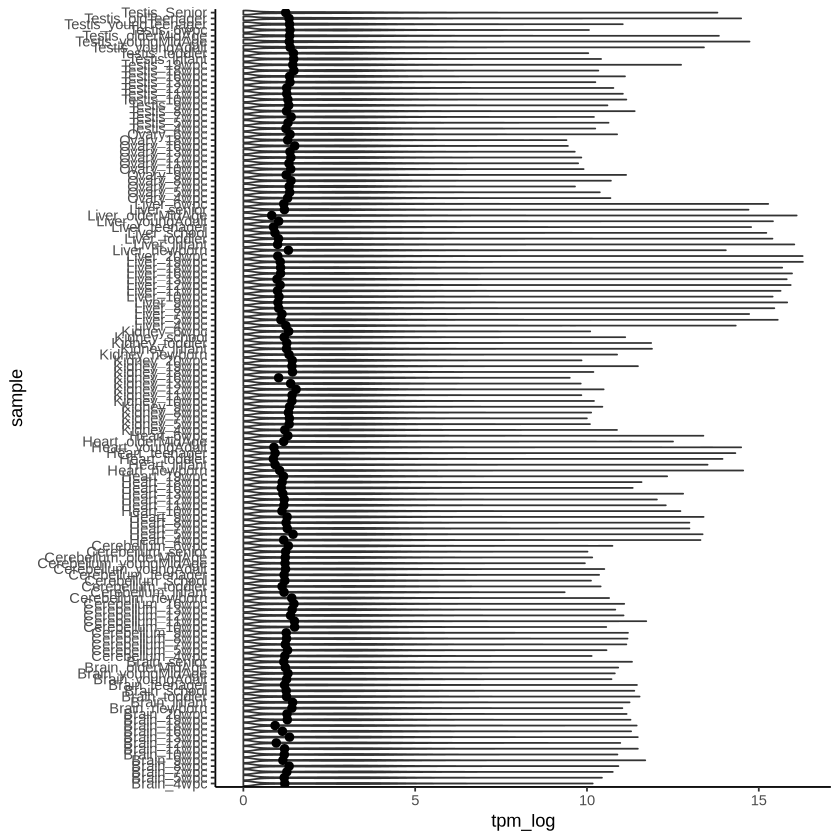

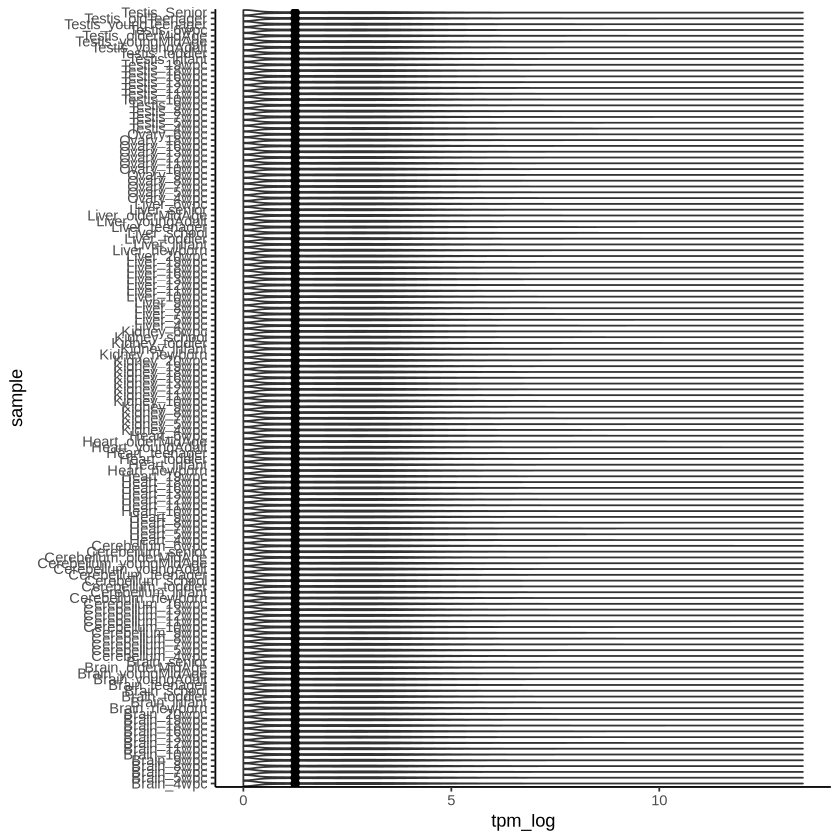

In [4]:
# quantile normalize expression distributions
exprmat.filt.norm <- normalize.quantiles(exprmat.filt)
rownames(exprmat.filt.norm) <- rownames(exprmat.filt)
colnames(exprmat.filt.norm) <- colnames(exprmat.filt)

p <- exprmat.filt %>% 
    melt() %>%
    'colnames<-'(c("hgnc_id", "sample", "tpm")) %>%
    mutate(tpm_log=log2(tpm+1)) %>%
    ggplot(aes(x=tpm_log, y=sample)) + geom_violin() + 
    stat_summary(fun=median, geom="point", size=2) + theme_classic()

p.norm <- exprmat.filt.norm %>% 
    melt() %>%
    'colnames<-'(c("hgnc_id", "sample", "tpm")) %>%
    mutate(tpm_log=log2(tpm+1)) %>%
    ggplot(aes(x=tpm_log, y=sample)) + geom_violin() + 
    stat_summary(fun=median, geom="point", size=2) + theme_classic()

p
p.norm

In [5]:
head(rowdata)

,source,type,gene_id,gene_type,gene_name,level,tag,havana_gene,artif_dupl,gene_id_base,⋯,hom_early_adult,hem_early_adult,sucessful_procedures_13,ortholog,gene_symbol,mean_depmap_gene_effect_score,depmap_essential_05,depmap_essential_1,fusil_all,fusil
,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
HGNC:5,HAVANA,gene,ENSG00000121410.12,protein_coding,A1BG,1,overlapping_locus,OTTHUMG00000183507.3,NA,ENSG00000121410,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:37133,HAVANA,gene,ENSG00000268895.6,lncRNA,A1BG-AS1,2,overlapping_locus,OTTHUMG00000183508.2,NA,ENSG00000268895,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:24086,HAVANA,gene,ENSG00000148584.16,protein_coding,A1CF,2,overlapping_locus,OTTHUMG00000018240.6,NA,ENSG00000148584,⋯,23,0,yes,one2one,A1CF,-0.07773930,n,n,VP,VP
HGNC:7,HAVANA,gene,ENSG00000175899.15,protein_coding,A2M,2,NA,OTTHUMG00000150267.7,NA,ENSG00000175899,⋯,19,0,yes,one2one,A2M,0.02673364,n,n,VP,VP
HGNC:27057,HAVANA,gene,ENSG00000245105.5,lncRNA,A2M-AS1,2,NA,OTTHUMG00000168289.4,NA,ENSG00000245105,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
HGNC:23336,HAVANA,gene,ENSG00000166535.20,protein_coding,A2ML1,2,NA,OTTHUMG00000128499.9,NA,ENSG00000166535,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [6]:
# Find max tissue

#function to find maximum expression column of return multiple if more than one
max.col <- function(vals){
    temp <- which(vals==max(vals))
    if(length(temp)==1){
        return(temp)
    } else if(length(temp)>1){
        return("multiple")
    } else{
        return(NA)}
}

max.col.tab <- data.frame("max_col_raw"=apply(exprmat.filt, 1, max.col)) %>%
    mutate("max_col_norm"=apply(exprmat.filt.norm, 1, max.col)) %>% 
    tibble::rownames_to_column(var="hgnc_id")
max.col.tab$max_sample_raw <- coldata$label[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_sample_norm <- coldata$label[max.col.tab$max_col_norm %>% as.numeric()]
max.col.tab$max_tissue_raw <- coldata$tissue[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_tissue_norm <- coldata$tissue[max.col.tab$max_col_norm %>% as.numeric()]
max.col.tab$max_stage_raw <- coldata$stage[max.col.tab$max_col_raw %>% as.numeric()]
max.col.tab$max_stage_norm <- coldata$stage[max.col.tab$max_col_norm %>% as.numeric()]

max.col.tab[which(max.col.tab$max_col_raw=="multiple"), c("max_sample_raw", "max_tissue_raw", "max_stage_raw")] <- rep("multiple", 3)
max.col.tab[which(max.col.tab$max_col_norm=="multiple"), c("max_sample_norm", "max_tissue_norm", "max_stage_norm")] <- rep("multiple", 3)

nrow(max.col.tab)
head(max.col.tab)

Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”
Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”
Warning message in max.col.tab$max_col_norm %>% as.numeric():
“NAs introduced by coercion”


[1] 23160

,hgnc_id,max_col_raw,max_col_norm,max_sample_raw,max_sample_norm,max_tissue_raw,max_tissue_norm,max_stage_raw,max_stage_norm
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,HGNC:5,99,99,Liver_olderMidAge,Liver_olderMidAge,Liver,Liver,olderMidAge,olderMidAge
2,HGNC:24086,99,99,Liver_olderMidAge,Liver_olderMidAge,Liver,Liver,olderMidAge,olderMidAge
3,HGNC:7,94,94,Liver_infant,Liver_infant,Liver,Liver,infant,infant
4,HGNC:23336,108,108,Ovary_11wpc,Ovary_11wpc,Ovary,Ovary,11wpc,11wpc
5,HGNC:41523,58,58,Heart_teenager,Heart_teenager,Heart,Heart,teenager,teenager
6,HGNC:30005,10,10,Brain_16wpc,Brain_16wpc,Brain,Brain,16wpc,16wpc


# Add to FUSIL table

In [7]:
fusil <- read.delim(fusil_file, as.is=T, sep = "\t", header = T)
fusil[fusil == '-'] <- NA

# view summary
print(paste("## FUSIL calls loaded: ", nrow(fusil)))

[1] "## FUSIL calls loaded:  8037"


In [8]:
fusil_additions <- left_join(fusil, max.col.tab, by="hgnc_id")
nrow(fusil_additions)
head(fusil_additions)

[1] 8037

,mgi_id,viability,wol,mp_term_id_homozygote,mp_term_id_heterozygote,mp_term_id_hemizygote,mp_term_name_homozygote,mp_term_name_heterozygote,mp_term_name_hemizygote,allele_symbol_homozygote,⋯,fusil_all,fusil,max_col_raw,max_col_norm,max_sample_raw,max_sample_norm,max_tissue_raw,max_tissue_norm,max_stage_raw,max_stage_norm
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,MGI:101759,viable,NA,MP:0001399|MP:0001406|MP:0005565|MP:0010088|MP:0005419,NA,NA,hyperactivity|abnormal gait|increased blood urea nitrogen level|decreased circulating fructosamine level|decreased circulating serum albumin level,NA,NA,Syt4<em2(IMPC)H>,⋯,VP,VP,35,35,Cerebellum_toddler,Cerebellum_toddler,Cerebellum,Cerebellum,toddler,toddler
2,MGI:101760,lethal,early lethal,MP:0013292|MP:0011100,MP:0005333|MP:0010506|MP:0010053|MP:0002941,NA,"embryonic lethality prior to organogenesis|preweaning lethality, complete penetrance",decreased heart rate|prolonged RR interval|decreased grip strength|increased circulating alanine transaminase level,NA,Sfswap<em1(IMPC)J>,⋯,CL,CL,26,105,Cerebellum_8wpc,Ovary_8wpc,Cerebellum,Ovary,8wpc,8wpc
3,MGI:101766,lethal,late lethal,MP:0011100|MP:0003984|MP:0001785|MP:0000111|MP:0000428|MP:0001711,MP:0000691|MP:0002135|MP:0000266|MP:0000689|MP:0001289|MP:0002060|MP:0000220|MP:0000274|MP:0006203|MP:0005013|MP:0003068|MP:0001711|MP:0000218,NA,"preweaning lethality, complete penetrance|embryonic growth retardation|edema|cleft palate|abnormal craniofacial morphology|abnormal placenta morphology",enlarged spleen|abnormal kidney morphology|abnormal heart morphology|abnormal spleen morphology|persistence of hyaloid vascular system|abnormal skin morphology|increased monocyte cell number|enlarged heart|eye hemorrhage|increased lymphocyte cell number|enlarged kidney|abnormal placenta morphology|increased leukocyte cell number,NA,Ryk<em1(IMPC)Mbp>,⋯,DL,DL,52,123,Heart_16wpc,Testis_16wpc,Heart,Testis,16wpc,16wpc
4,MGI:101769,lethal,early lethal,MP:0013292|MP:0011100,MP:0003984|MP:0002092|MP:0000702|MP:0002590|MP:0001297|MP:0002339|MP:0010052|MP:0000692|MP:0002188|MP:0001293|MP:0000266,NA,"embryonic lethality prior to organogenesis|preweaning lethality, complete penetrance",embryonic growth retardation|abnormal eye morphology|enlarged lymph nodes|increased mean corpuscular volume|microphthalmia|abnormal lymph node morphology|increased grip strength|small spleen|small heart|anophthalmia|abnormal heart morphology,NA,Mcl1<em1(IMPC)Mbp>,⋯,CL,CL,93,127,Liver_newborn,Testis_toddler,Liver,Testis,newborn,toddler
5,MGI:101770,viable,NA,MP:0004906|MP:0002092|MP:0001102|MP:0001488,NA,NA,enlarged uterus|abnormal eye morphology|small superior vagus ganglion|increased startle reflex,NA,NA,Bfsp1<tm1b(EUCOMM)Wtsi>,⋯,VP,VP,107,110,Ovary_10wpc,Ovary_13wpc,Ovary,Ovary,10wpc,13wpc
6,MGI:101774,viable,NA,NA,NA,NA,NA,NA,NA,NA,⋯,VnP_insufficient_procedures,NA,91,91,Liver_19wpc,Liver_19wpc,Liver,Liver,19wpc,19wpc


# save output

In [9]:
saveRDS(fusil_additions, file=paste0(out.file.prefix, "max_tissue.rds"))
write.table(fusil_additions, quote=F, row.names=F, sep="\t", file=paste0(out.file.prefix, "max_tissue.tsv"))